# Federated MedMNIST 3D con Flower

Questo notebook adatta l'esperimento originale (basato su OpenFL) al framework **Flower**.

Componenti principali:
- **Dataset**: MedMNIST 3D (`synapsemnist3d`)
- **Modello**: CNN 3D nativa (`Net3D`) con `Conv3d`, `BatchNorm3d`, `MaxPool3d`
- **Federated Learning**: Flower `NumPyClient` + `FedAvg` + simulazione in-process

**Differenze rispetto alla versione OpenFL:**
| OpenFL | Flower |
|--------|--------|
| `Director` / `Envoy` (processi separati) | Simulazione in-process con Ray |
| `DataInterface`, `TaskInterface`, `ModelInterface` | `NumPyClient` (unica classe) |
| `FLExperiment.start()` | `fl.simulation.start_simulation()` |
| `Conv3dConverter` (ACSConv) per la conversione 2D→3D | `Net3D` scritta direttamente in 3D |
| Workspace zip trasferito ai collaborator | Tutto gira in locale |

## 1 — Installazione dipendenze

In [8]:
!pip install "flwr[simulation]" medmnist

## 2 — Import e configurazione globale

In [9]:
import os
import warnings

warnings.filterwarnings("ignore")
os.environ["FLWR_TELEMETRY_ENABLED"] = "0"   # disabilita telemetria Flower

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from typing import List, Tuple

import medmnist
from medmnist import INFO
from medmnist.evaluator import getACC

import flwr as fl
from flwr.client import NumPyClient

print(f"PyTorch  : {torch.__version__}")
print(f"Flower   : {fl.__version__}")
print(f"MedMNIST : {medmnist.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")

PyTorch  : 2.12.0+cu130
Flower   : 1.29.0
MedMNIST : 3.0.2
CUDA     : False


In [10]:
# ── Iperparametri globali ──────────────────────────────────────────────────────
DATA_FLAG     = "synapsemnist3d"   # dataset MedMNIST 3D
NUM_CLIENTS   = 2                  # numero di client federati (SuperNode)
NUM_ROUNDS    = 3                  # round di aggregazione FedAvg
LOCAL_EPOCHS  = 1                  # epoche locali per round
BATCH_SIZE    = 64
LR            = 0.001

# ── Info dataset ──────────────────────────────────────────────────────────────
info      = INFO[DATA_FLAG]
TASK      = info["task"]
N_CHANNELS = info["n_channels"]
N_CLASSES  = len(info["label"])
DataClass  = getattr(medmnist, info["python_class"])

print(f"Dataset  : {DATA_FLAG}")
print(f"Task     : {TASK}")
print(f"Channels : {N_CHANNELS}  |  Classes: {N_CLASSES}")
print(info)

Dataset  : synapsemnist3d
Task     : binary-class
Channels : 1  |  Classes: 2
{'python_class': 'SynapseMNIST3D', 'description': 'The SynapseMNIST3D is a new 3D volume dataset to classify whether a synapse is excitatory or inhibitory. It uses a 3D image volume of an adult rat acquired by a multi-beam scanning electron microscope. The original data is of the size 100×100×100um^3 and the resolution 8×8×30nm^3, where a (30um)^3 sub-volume was used in the MitoEM dataset with dense 3D mitochondria instance segmentation labels. Three neuroscience experts segment a pyramidal neuron within the whole volume and proofread all the synapses on this neuron with excitatory/inhibitory labels. For each labeled synaptic location, we crop a 3D volume of 1024×1024×1024nm^3 and resize it into 28×28×28 voxels. Finally, the dataset is randomly split with a ratio of 7:1:2 into training, validation and test set.', 'url': 'https://zenodo.org/records/10519652/files/synapsemnist3d.npz?download=1', 'MD5': '1235b78

## 3 — Dataset e Data Loading

Sostituisce `DataInterface` + `TransformedDataset` di OpenFL con classi standard PyTorch.  
Il training set viene suddiviso uniformemente tra i `NUM_CLIENTS` client.

In [11]:
class Transform3D:
    """Normalizza un volume 3D e applica opzionalmente uno scaling."""

    def __init__(self, mul=None):
        self.mul = mul

    def __call__(self, voxel: np.ndarray) -> np.ndarray:
        if self.mul == "random":
            voxel = voxel * np.random.uniform(0, 1)
        elif self.mul is not None:
            voxel = voxel * float(self.mul)
        return voxel.astype(np.float32)


class MedMNIST3DDataset(Dataset):
    """Wrapper per dataset MedMNIST 3D con normalizzazione e transform.

    MedMNIST 3D restituisce immagini con shape (C, D, H, W) dove C=n_channels.
    Si normalizza in [0,1] senza aggiungere dimensioni extra.
    """

    def __init__(self, medmnist_ds, transform=None):
        self.dataset   = medmnist_ds
        self.transform = transform

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        img, label = self.dataset[index]
        # img ha già shape (C, D, H, W) — normalizza senza aggiungere assi
        img = img.astype(np.float32) / 255.0
        if self.transform is not None:
            img = self.transform(img)
        return (
            torch.tensor(img, dtype=torch.float32),
            torch.tensor(label.astype(int)),   # shape (1,)
        )

In [12]:
def load_data(
    partition_id: int,
    num_partitions: int,
    train_bs: int = BATCH_SIZE,
    val_bs: int = 512,
) -> Tuple[DataLoader, DataLoader]:
    """Scarica MedMNIST e restituisce i loader per il client `partition_id`.

    Il training set viene diviso in `num_partitions` slice contigue.
    Il validation set rimane completo per ogni client (valutazione globale).
    """
    train_transform = Transform3D()
    eval_transform  = Transform3D()

    raw_train = DataClass(split="train", download=True)
    raw_val   = DataClass(split="val",   download=True)

    # Partizionamento uniforme del training set
    n_total   = len(raw_train)
    per_slice = n_total // num_partitions
    start     = partition_id * per_slice
    end       = start + per_slice if partition_id < num_partitions - 1 else n_total
    indices   = list(range(start, end))

    train_ds  = MedMNIST3DDataset(raw_train, transform=train_transform)
    val_ds    = MedMNIST3DDataset(raw_val,   transform=eval_transform)

    trainloader = DataLoader(Subset(train_ds, indices), batch_size=train_bs, shuffle=True,  num_workers=0)
    valloader   = DataLoader(val_ds,                    batch_size=val_bs,   shuffle=False, num_workers=0)

    return trainloader, valloader


# ── Verifica rapida ──────────────────────────────────────────────────────────
tl, vl = load_data(partition_id=0, num_partitions=NUM_CLIENTS)
sample, target = next(iter(tl))
print(f"Train batches: {len(tl)}  |  Batch shape: {sample.shape}  |  Label shape: {target.shape}")
print(f"Val   batches: {len(vl)}")

Train batches: 10  |  Batch shape: torch.Size([64, 1, 28, 28, 28])  |  Label shape: torch.Size([64, 1])
Val   batches: 1


## 4 — Definizione del modello

`Net3D` è una CNN scritta **direttamente in 3D** con layer `Conv3d`, `BatchNorm3d` e `MaxPool3d`.  
Questa è la versione equivalente alla `Net` originale dopo la conversione con ACSConv,  
ma senza la dipendenza esterna — più robusta con versioni recenti di PyTorch.

Dimensioni spaziali su input `28×28×28`:
- layer1 (Conv3d 3): `26×26×26`
- layer2 (Conv3d 3 + MaxPool3d 2): `24×24×24` → `12×12×12`
- layer3 (Conv3d 3): `10×10×10`
- layer4 (Conv3d 3): `8×8×8`
- layer5 (Conv3d 3 p=1 + MaxPool3d 2): `8×8×8` → `4×4×4`
- fc: `64 × 4 × 4 × 4 = 4096 → 128 → num_classes`

In [13]:
class Net3D(nn.Module):
    """CNN 3D nativa — equivalente alla Net originale dopo conversione ACSConv."""

    def __init__(self, in_channels: int, num_classes: int):
        super().__init__()
        self.layer1 = nn.Sequential(nn.Conv3d(in_channels, 16, 3), nn.BatchNorm3d(16), nn.ReLU())
        self.layer2 = nn.Sequential(nn.Conv3d(16, 16, 3),          nn.BatchNorm3d(16), nn.ReLU(), nn.MaxPool3d(2, 2))
        self.layer3 = nn.Sequential(nn.Conv3d(16, 64, 3),          nn.BatchNorm3d(64), nn.ReLU())
        self.layer4 = nn.Sequential(nn.Conv3d(64, 64, 3),          nn.BatchNorm3d(64), nn.ReLU())
        self.layer5 = nn.Sequential(nn.Conv3d(64, 64, 3, padding=1), nn.BatchNorm3d(64), nn.ReLU(), nn.MaxPool3d(2, 2))
        self.fc = nn.Sequential(
            nn.Linear(64 * 4 * 4 * 4, 128), nn.ReLU(),
            nn.Linear(128, 128),             nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.layer5(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


def build_model() -> nn.Module:
    return Net3D(in_channels=N_CHANNELS, num_classes=N_CLASSES)


# ── Verifica architettura ────────────────────────────────────────────────────
model_test = build_model()
dummy = torch.zeros(2, N_CHANNELS, 28, 28, 28)   # batch=2, C=1, D=28, H=28, W=28
out   = model_test(dummy)
print(f"Output shape: {out.shape}  (atteso: [2, {N_CLASSES}])")
n_params = sum(p.numel() for p in model_test.parameters())
print(f"Parametri totali: {n_params:,}")
del model_test, dummy, out

Output shape: torch.Size([2, 2])  (atteso: [2, 2])
Parametri totali: 798,034


## 5 — Flower Client

`MedMNISTClient` estende `fl.client.NumPyClient` e implementa i tre metodi del protocollo federato:

| Metodo | Equivalente OpenFL | Descrizione |
|--------|--------------------|-------------|
| `get_parameters` | `ModelInterface` (pesi iniziali) | Serializza i pesi del modello in array NumPy |
| `fit` | `@TI.register_fl_task` `train` | Allenamento locale + ritorno dei pesi aggiornati |
| `evaluate` | `@TI.register_fl_task` `validate` | Valutazione sul set di validazione |


In [14]:
def get_parameters(model: nn.Module) -> List[np.ndarray]:
    """Estrae i pesi del modello come lista di array NumPy."""
    return [val.cpu().numpy() for val in model.state_dict().values()]


def set_parameters(model: nn.Module, parameters: List[np.ndarray]) -> None:
    """Carica i pesi ricevuti (aggregati) nel modello locale."""
    state_dict = {
        k: torch.tensor(v)
        for k, v in zip(model.state_dict().keys(), parameters)
    }
    model.load_state_dict(state_dict, strict=True)


class MedMNISTClient(NumPyClient):
    """Client Flower per addestramento federato su MedMNIST 3D."""

    def __init__(self, partition_id: int, num_partitions: int):
        self.partition_id   = partition_id
        self.device         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.trainloader, self.valloader = load_data(partition_id, num_partitions)
        self.model          = build_model().to(self.device)
        self.criterion      = nn.CrossEntropyLoss()

    # ── Protocollo NumPyClient ───────────────────────────────────────────────

    def get_parameters(self, config):
        return get_parameters(self.model)

    def fit(self, parameters, config):
        set_parameters(self.model, parameters)
        self.model.train()
        optimizer = torch.optim.Adam(self.model.parameters(), lr=LR)

        losses = []
        for _ in range(LOCAL_EPOCHS):
            for inputs, targets in self.trainloader:
                inputs  = inputs.to(self.device)
                targets = targets.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(inputs)
                if TASK == "multi-label, binary-class":
                    loss = self.criterion(outputs, targets.squeeze().float())
                else:
                    loss = self.criterion(outputs, targets.squeeze().long())
                loss.backward()
                optimizer.step()
                losses.append(loss.item())

        num_examples = len(self.trainloader.dataset)
        metrics = {"train_loss": float(np.mean(losses))}
        print(f"  [client {self.partition_id}] fit — loss={metrics['train_loss']:.4f}, samples={num_examples}")
        return get_parameters(self.model), num_examples, metrics

    def evaluate(self, parameters, config):
        set_parameters(self.model, parameters)
        self.model.eval()

        losses, y_scores, y_labels = [], [], []
        with torch.no_grad():
            for inputs, targets in self.valloader:
                outputs = self.model(inputs.to(self.device))
                loss    = self.criterion(outputs, targets.to(self.device).squeeze().long())
                losses.append(loss.item())
                probs = F.softmax(outputs, dim=1).cpu().numpy()
                y_scores.append(probs)
                y_labels.append(targets.numpy())

        y_score = np.concatenate(y_scores, axis=0)  # (N, C)
        y_true  = np.concatenate(y_labels, axis=0)  # (N, 1)
        acc     = getACC(y_true, y_score, TASK)
        avg_loss = float(np.mean(losses))

        num_examples = len(self.valloader.dataset)
        print(f"  [client {self.partition_id}] eval  — loss={avg_loss:.4f}, acc={acc:.4f}")
        return avg_loss, num_examples, {"accuracy": float(acc)}

## 6 — Strategia di aggregazione: FedAvg

Sostituisce `FLExperiment` di OpenFL. `FedAvg` è la strategia di default di Flower:  
aggrega i pesi dei client con media pesata sul numero di campioni.

In [15]:
strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,             # usa tutti i client disponibili per il training
    fraction_evaluate=1.0,        # usa tutti i client per la valutazione
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
)
print("Strategia FedAvg configurata.")

Strategia FedAvg configurata.


## 7 — Avvio della simulazione federata

`fl.simulation.start_simulation` lancia un cluster Ray in-process e simula `NUM_CLIENTS` client virtuali.  
Equivale all'`FLExperiment.start()` di OpenFL ma senza processi Director/Envoy separati.

In [16]:
def client_fn(context):
    """Factory chiamata da Flower per istanziare un client virtuale.

    `context.node_config['partition-id']` contiene l'ID univoco del client.
    Corrisponde al shard_descriptor assegnato dall'Envoy in OpenFL.
    """
    partition_id = int(context.node_config["partition-id"])
    return MedMNISTClient(partition_id, NUM_CLIENTS).to_client()


print(f"Avvio simulazione: {NUM_CLIENTS} client, {NUM_ROUNDS} round, {LOCAL_EPOCHS} epoca/round")
print("-" * 60)

history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=NUM_ROUNDS),
    strategy=strategy,
    client_resources={"num_cpus": 1, "num_gpus": 0.0},
)

Avvio simulazione: 2 client, 3 round, 1 epoca/round
------------------------------------------------------------


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=3, no round_timeout
2026-05-19 15:51:07,218	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:172.21.149.59': 1.0, 'object_store_memory': 4210778112.0, 'CPU': 8.0, 'memory': 9825148928.0, 'node:__internal_head__': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineAc

(ClientAppActor pid=70434)   [client 0] fit — loss=0.0810, samples=615


INFO :      aggregate_fit: received 2 results and 0 failures
INFO :      configure_evaluate: strategy sampled 2 clients (out of 2)
(pid=gcs_server) [2026-05-19 15:51:36,556 E 70259 70259] (gcs_server) gcs_server.cc:302: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(ClientAppActor pid=70430) [2026-05-19 15:51:38,342 E 70430 70571] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
[2026-05-19 15:51:38,402 E 69485 70429] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(raylet) [2026-05-

(ClientAppActor pid=70434)   [client 0] eval  — loss=0.5936, acc=0.7288
(ClientAppActor pid=70437)   [client 1] fit — loss=0.8119, samples=615


...

(ClientAppActor pid=70437)   [client 1] eval  — loss=0.5939, acc=0.7288


INFO :      aggregate_fit: received 2 results and 0 failures
INFO :      configure_evaluate: strategy sampled 2 clients (out of 2)


(ClientAppActor pid=70434)   [client 0] fit — loss=0.0021, samples=615 [repeated 2x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(ClientAppActor pid=70434)   [client 0] eval  — loss=0.5939, acc=0.7288


INFO :      aggregate_evaluate: received 2 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 3 round(s) in 75.58s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.5935880541801453
INFO :      		round 2: 0.5938572883605957
INFO :      		round 3: 0.5934053659439087
INFO :      


(ClientAppActor pid=70437)   [client 1] eval  — loss=0.5934, acc=0.7288
(ClientAppActor pid=70434)   [client 0] eval  — loss=0.5934, acc=0.7288


## 8 — Analisi dei risultati

Equivale a `fl_experiment.stream_metrics()` di OpenFL.

In [17]:
print("\n=== RISULTATI FEDERATI ===")
print("\nLoss centralizzata (server):")
for rnd, loss in history.losses_centralized:
    print(f"  Round {rnd}: {loss:.4f}")

print("\nLoss distribuita (media client):")
for rnd, loss in history.losses_distributed:
    print(f"  Round {rnd}: {loss:.4f}")

print("\nMetriche distribuite (accuracy):")
for metric_name, rounds_values in history.metrics_distributed.items():
    print(f"  {metric_name}:")
    for rnd, val in rounds_values:
        print(f"    Round {rnd}: {val:.4f}")


=== RISULTATI FEDERATI ===

Loss centralizzata (server):

Loss distribuita (media client):
  Round 1: 0.5936
  Round 2: 0.5939
  Round 3: 0.5934

Metriche distribuite (accuracy):


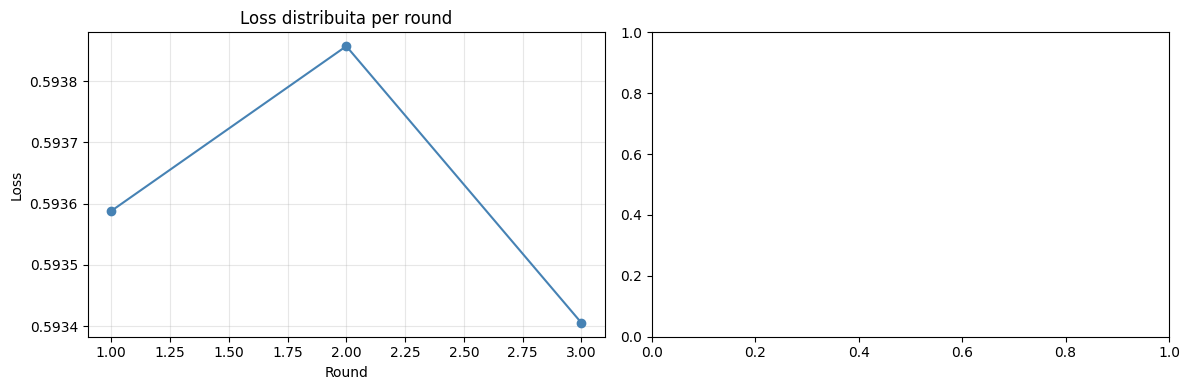

Grafico salvato in medmnist3d_flower_results.png


In [18]:
# ── Plot opzionale (richiede matplotlib) ────────────────────────────────────
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss distribuita
    if history.losses_distributed:
        rounds, losses = zip(*history.losses_distributed)
        axes[0].plot(rounds, losses, marker="o", color="steelblue")
        axes[0].set_title("Loss distribuita per round")
        axes[0].set_xlabel("Round")
        axes[0].set_ylabel("Loss")
        axes[0].grid(True, alpha=0.3)

    # Accuracy distribuita
    if "accuracy" in history.metrics_distributed:
        rounds, accs = zip(*history.metrics_distributed["accuracy"])
        axes[1].plot(rounds, accs, marker="o", color="darkorange")
        axes[1].set_title("Accuracy distribuita per round")
        axes[1].set_xlabel("Round")
        axes[1].set_ylabel("Accuracy")
        axes[1].set_ylim(0, 1)
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("medmnist3d_flower_results.png", dpi=120)
    plt.show()
    print("Grafico salvato in medmnist3d_flower_results.png")

except ImportError:
    print("matplotlib non installato — installa con: pip install matplotlib")